## Pooling Functions

Pooling functions reduce the spatial dimensions of an input (often an image or feature map) while retaining important features. The following table summarizes some common pooling operations used in deep learning:

| **Pooling Function**       | **Operation**                                                                                                               | **Notes** |
|----------------------------|-------------------------------------------------------------------------------------------------------------------------------|-----------|
| **Max Pooling**            | $Y_{ij} = \max_{(m,n) \in \text{window}} X_{ij}$   <br> (for each pooling window)                                             | Retains the maximum value. Often used to capture strong activations. |
| **Average Pooling**        | $Y_{ij} = \frac{1}{\text{window}} \sum_{(m,n) \in \text{window}} X_{ij}$   <br> (for each window)                              | Computes the average value over the window. |
| **Global Max Pooling**     | $Y = \max_{i,j} X_{ij}$                                                                                                        | Collapses spatial dimensions by taking the maximum value of the entire feature map. |
| **Global Average Pooling** | $Y = \frac{1}{HW} \sum_{i=1}^{H} \sum_{j=1}^{W} X_{ij}$                                                                      | Averages all elements in the feature map. |

These operations are essential for reducing the number of parameters and controlling overfitting in convolutional neural networks (CNNs).


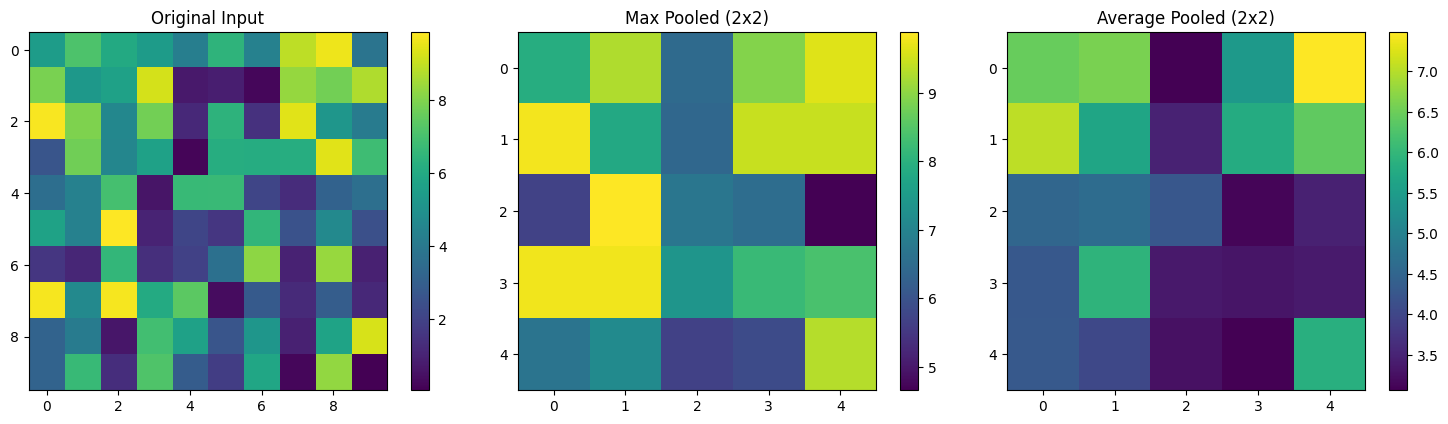

Global Max Pooling Result: 9.88
Global Average Pooling Result: 4.73


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def max_pool2d(input_array, pool_size=(2,2), stride=2):
    """
    Applies 2D max pooling on a 2D input array.
    """
    h, w = input_array.shape
    ph, pw = pool_size
    out_h = (h - ph) // stride + 1
    out_w = (w - pw) // stride + 1
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            w_start = j * stride
            window = input_array[h_start:h_start+ph, w_start:w_start+pw]
            output[i, j] = np.max(window)
    return output

def avg_pool2d(input_array, pool_size=(2,2), stride=2):
    """
    Applies 2D average pooling on a 2D input array.
    """
    h, w = input_array.shape
    ph, pw = pool_size
    out_h = (h - ph) // stride + 1
    out_w = (w - pw) // stride + 1
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            h_start = i * stride
            w_start = j * stride
            window = input_array[h_start:h_start+ph, w_start:w_start+pw]
            output[i, j] = np.mean(window)
    return output

def global_max_pool2d(input_array):
    """
    Applies global max pooling on a 2D input array, resulting in a single scalar output.
    """
    return np.max(input_array)

def global_avg_pool2d(input_array):
    """
    Applies global average pooling on a 2D input array, resulting in a single scalar output.
    """
    return np.mean(input_array)

# Create an example 2D input array (e.g., a 10x10 feature map)
np.random.seed(0)
input_data = np.random.rand(10, 10) * 10  # Random values scaled up for visualization

# Apply pooling functions
max_pooled = max_pool2d(input_data, pool_size=(2,2), stride=2)
avg_pooled = avg_pool2d(input_data, pool_size=(2,2), stride=2)
global_max = global_max_pool2d(input_data)
global_avg = global_avg_pool2d(input_data)

# Plot the original input and pooled outputs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(input_data, cmap='viridis')
axes[0].set_title('Original Input')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(max_pooled, cmap='viridis')
axes[1].set_title('Max Pooled (2x2)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(avg_pooled, cmap='viridis')
axes[2].set_title('Average Pooled (2x2)')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

# Print out the global pooling results
print(f"Global Max Pooling Result: {global_max:.2f}")
print(f"Global Average Pooling Result: {global_avg:.2f}")


### Additional Notes

- **Max Pooling:** Extracts the maximum value within each window, preserving prominent features.
- **Average Pooling:** Computes the average value within each window, which can help smooth the input.
- **Global Pooling:** Collapses the entire spatial dimension (e.g., a feature map) into a single value.

These pooling operations are essential steps in convolutional neural networks (CNNs) to reduce spatial dimensions and the number of parameters. They also help in achieving translation invariance.
